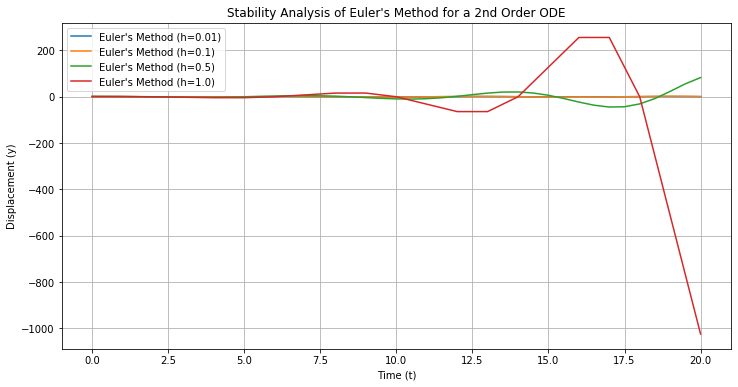

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values
# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

Step size h = 0.01
Coefficient matrix A:
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)


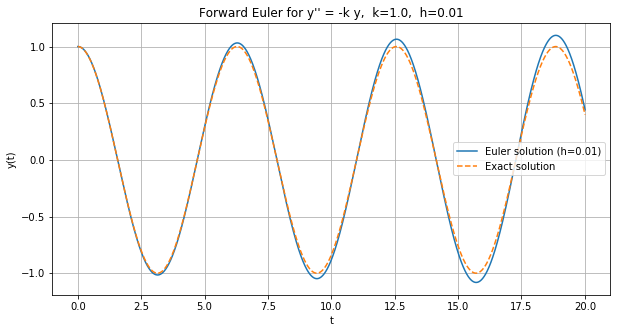

Step size h = 0.1
Coefficient matrix A:
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)


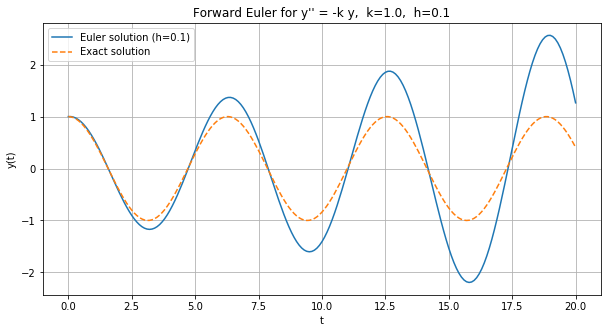

Step size h = 0.5
Coefficient matrix A:
[[ 1.   0.5]
 [-0.5  1. ]]
Eigenvalues: [1.+0.5j 1.-0.5j]
Magnitudes: [1.11803399 1.11803399]
Solution may not be Entirely Stable ;)


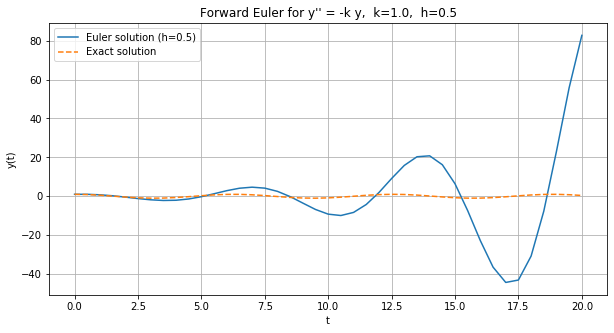

Step size h = 1.0
Coefficient matrix A:
[[ 1.  1.]
 [-1.  1.]]
Eigenvalues: [1.+1.j 1.-1.j]
Magnitudes: [1.41421356 1.41421356]
Solution may not be Entirely Stable ;)


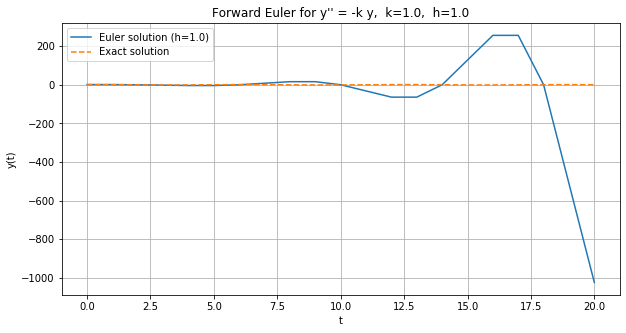

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size
def euler_matrix(h, k):
    return np.array([
        [1.0,   h],
        [-h*k,  1.0]], dtype=float)

def check_stability(h, k):
    A = euler_matrix(h, k)
    eigvals = np.linalg.eigvals(A)
    magnitudes = np.abs(eigvals)
    stable = np.all(magnitudes < 1)
    return A, eigvals, magnitudes, stable

def euler_method(h, k, t_start, t_end, y0, v0):
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    y[0] = y0
    v[0] = v0

    for n in range(len(t) - 1):
        y[n + 1] = y[n] + h * v[n]
        v[n + 1] = v[n] - h * k * y[n]

    return t, y, v

# Exact solution for comparison when v0 = 0 and y0 = 1
def exact_solution(t, k):
    return np.cos(np.sqrt(k) * t)

# Output + plots

for h in h_values:
    A, eigvals, mags, stable = check_stability(h, k)

    print("=" * 60)
    print(f"Step size h = {h}")
    print("Coefficient matrix A:")
    print(A)
    print(f"Eigenvalues: {eigvals}")
    print(f"Magnitudes: {mags}")

    if stable:
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    t, y, v = euler_method(h, k, t_start, t_end, y0, v0)
    y_exact = exact_solution(t, k)

    plt.figure(figsize=(10, 5))
    plt.plot(t, y, label=f"Euler solution (h={h})")
    plt.plot(t, y_exact, "--", label="Exact solution")
    plt.xlabel("t")
    plt.ylabel("y(t)")
    plt.title(f"Forward Euler for y'' = -k y,  k={k},  h={h}")
    plt.legend()
    plt.grid(True)
    plt.show()

Step size h = 0.01
Coefficient matrix:
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)
Step size h = 0.1
Coefficient matrix:
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)
Step size h = 0.5
Coefficient matrix:
[[ 1.   0.5]
 [-0.5  1. ]]
Eigenvalues: [1.+0.5j 1.-0.5j]
Magnitudes: [1.11803399 1.11803399]
Solution may not be Entirely Stable ;)
Step size h = 1.0
Coefficient matrix:
[[ 1.  1.]
 [-1.  1.]]
Eigenvalues: [1.+1.j 1.-1.j]
Magnitudes: [1.41421356 1.41421356]
Solution may not be Entirely Stable ;)


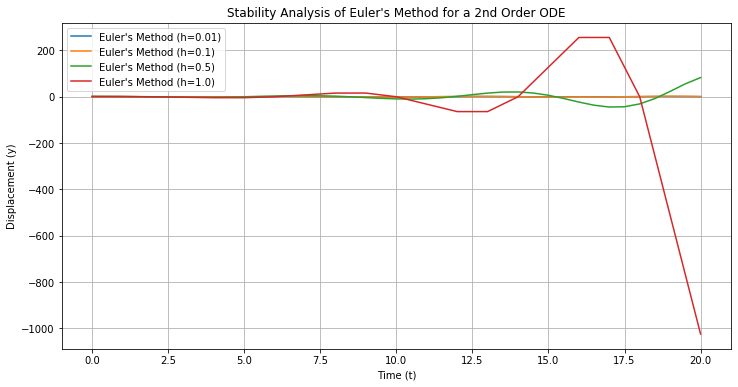

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity

# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    
    return t_values, y_values

def euler_matrix(h, k):
    return np.array([
        [1, h],
        [-h*k, 1]
    ])

def check_stability(h, k):
    A = euler_matrix(h, k)
    eigenvalues = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvalues)
    
    if np.all(magnitudes < 1):
        stability_message = "Solution is Stable"
    else:
        stability_message = "Solution may not be Entirely Stable ;)"
    
    return A, eigenvalues, magnitudes, stability_message

# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    A, eigenvalues, magnitudes, message = check_stability(h, k)
    
    print(f"Step size h = {h}")
    print("Coefficient matrix:")
    print(A)
    print(f"Eigenvalues: {eigenvalues}")
    print(f"Magnitudes: {magnitudes}")
    print(message)

    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()